## ⚙️ Intalación y Configuración de la Instancia de Langfuse

In [1]:
!pip install langfuse
!pip install python-dotenv
!pip install -U matplotlib

Defaulting to user installation because normal site-packages is not writeable
    python-dotenv (>=0.13.*) ; extra == 'standard'
                   ~~~~~~~^
Defaulting to user installation because normal site-packages is not writeable
    python-dotenv (>=0.13.*) ; extra == 'standard'
                   ~~~~~~~^
Defaulting to user installation because normal site-packages is not writeable
    python-dotenv (>=0.13.*) ; extra == 'standard'
                   ~~~~~~~^


In [2]:
import os
from langfuse import Langfuse
from dotenv import load_dotenv

# Cargar las variables desde el archivo .env
load_dotenv()

# Acceder a las variables
LANGFUSE_PUBLIC_KEY = os.getenv("LANGFUSE_PUBLIC_KEY")
LANGFUSE_SECRET_KEY = os.getenv("LANGFUSE_SECRET_KEY")
LANGFUSE_HOST = os.getenv("LANGFUSE_HOST")

# Configurar intancia de Langfuse 
langfuse = Langfuse(
    public_key=LANGFUSE_PUBLIC_KEY,
    secret_key=LANGFUSE_SECRET_KEY,
    host=LANGFUSE_HOST
)

## ⬇️ Obtener Trazas y Extrear Información

In [3]:
# Obtener las trazas generadas sin un umbral
no_th_traces = langfuse.api.trace.list(limit=100, name="retrival-no-th")

# Extraer información relevante (input, output, retrieval score and question category)
traces_input = [t.input for t in no_th_traces.data]
traces_output = [t.output for t in no_th_traces.data]
ret_scores = [t.metadata['attributes']['retrieval.score'] for t in no_th_traces.data]
q_categories = [t.metadata['attributes']['category'] for t in no_th_traces.data]

## ✅ Obtener Precisón (`accuracy`) de las Trazas

In [4]:
# Obtener precisión de las trazas usando trace_id
traces_accuracy = [langfuse.api.score_v_2.get(trace_id=t.id).data[0].value for t in no_th_traces.data]

## 🛠️ Construir un DataFrame con Información de las Traas y su Precisión

In [5]:
import pandas as pd

# Construir el DataFrame
traces_df = pd.DataFrame({'input': traces_input, 'output': traces_output, 'category': q_categories, 'retrieval_score': ret_scores, 'accuracy': traces_accuracy})

# Castear el tipo de las columnas
traces_df = traces_df.astype({
  'input': 'string',
  'output': 'string',
  'retrieval_score': 'float64',
  'accuracy': 'int64'
})

traces_df[:5]

,input,output,category,retrieval_score,accuracy
0,¿Durante qué meses se va a dictar el curso de ...,Quienes cursen el Curso de Nivelación podrán o...,Ingreso,0.871011,0
1,¿Dónde quedan las baterías R?,Las aulas D están ubicadas en las Baterías D: ...,Cursado,0.557605,1
2,¿Cómo se si debo inscribirme en una materia co...,El régimen de correlatividades de cada carrera...,Ingreso,0.927217,1
3,Si quiero cambiarme de facultad y entrar a FAM...,Para solicitar cambiar de carrera o cursar en ...,Ingreso,0.801719,0
4,¿Dónde publican las fechas finales de los exám...,"Ingresá a Guaraní. Una vez dentro, seleccioná ...",Exámenes,0.714493,0


## ↔️ Dividir las Trazas

Las trazas se dividirán en

* `correct` (`accuracy = 1`)
* `incorrect` (`accuracy = 0`)
* `no_info` (`category = 'Sin Información'`)

In [6]:
# División en 'correct' e 'incorrect'
correct = traces_df[traces_df['accuracy'] == 1]
incorrect = traces_df[traces_df['accuracy'] == 0]

# Extrear trazas de consultas con categoria 'Sin Información' 
no_info = traces_df[traces_df['category'] == 'Sin Información']

In [7]:
correct[:5]

,input,output,category,retrieval_score,accuracy
1,¿Dónde quedan las baterías R?,Las aulas D están ubicadas en las Baterías D: ...,Cursado,0.557605,1
2,¿Cómo se si debo inscribirme en una materia co...,El régimen de correlatividades de cada carrera...,Ingreso,0.927217,1
5,¿Cuáles son los pasos para anotarse al Régimen...,Para inscribirte al Régimen Especial de Cursad...,Cursado,0.868865,1
6,¿Qué papeles tengo que presentar para completa...,La Inscripción Definitiva suele realizarse a p...,Ingreso,0.963276,1
7,¿Cómo puedo tramitar el ingreso a FAMAF desde ...,Para solicitar ingresar a una carrera de FAMAF...,Ingreso,0.762979,1


In [8]:
incorrect[:5]

,input,output,category,retrieval_score,accuracy
0,¿Durante qué meses se va a dictar el curso de ...,Quienes cursen el Curso de Nivelación podrán o...,Ingreso,0.871011,0
3,Si quiero cambiarme de facultad y entrar a FAM...,Para solicitar cambiar de carrera o cursar en ...,Ingreso,0.801719,0
4,¿Dónde publican las fechas finales de los exám...,"Ingresá a Guaraní. Una vez dentro, seleccioná ...",Exámenes,0.714493,0
9,¿Dónde consulto las fechas exactas de las mesa...,"Ingresá a Guaraní. Una vez dentro, seleccioná ...",Exámenes,0.664508,0
10,¿Están publicadas las fechas definitivas para ...,El Trabajo Especial se puede rendir durante la...,Exámenes,0.614375,0


In [9]:
no_info[:5]

,input,output,category,retrieval_score,accuracy
50,¿Cómo puedo volverme parte del Centro de Estud...,Para inscribirte al Régimen Especial de Cursad...,Sin Información,0.621829,0
53,¿Dónde se suben las tesis y los trabajos espec...,Las inscripciones al trabajo especial se recep...,Sin Información,0.721553,0
57,¿Cómo obtengo mi cuenta en el aula virtual?,"Ingresá a Guaraní. Una vez dentro, seleccioná ...",Sin Información,0.657579,0
66,¿Cómo me inscribo al curso de nivelación no in...,La preinscripción al Curso de Nivelación de FA...,Sin Información,0.868850,0
74,¿Como puedo inscribirme como alumno vocacional?,"Ingresá a Guaraní. Una vez dentro, seleccioná ...",Sin Información,0.717428,0


## 📊 Gráficos de la Distribución de `retrieval_score`

In [10]:
import matplotlib.pyplot as plt
import numpy as np

# Valor definido como threshold
threshold_val = 0.73

### 📦 Box Plots

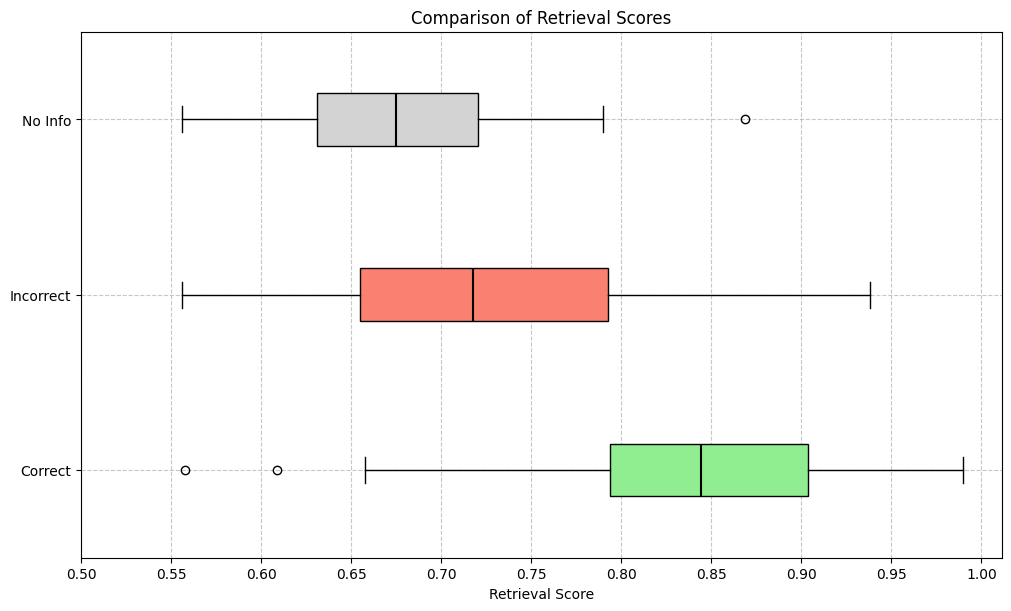

In [11]:
import matplotlib.pyplot as plt
import numpy as np

# Lista de datos a graficar
datos = [correct.retrieval_score, incorrect.retrieval_score, no_info.retrieval_score]

plt.figure(layout='constrained', figsize=(10, 6))

# Boxplots
bplot = plt.boxplot(datos, 
                    orientation='horizontal',
                    patch_artist=True,
                    tick_labels=['Correct', 'Incorrect', 'No Info']) # Etiquetas

# Colores para las etiquetas
colors = ['lightgreen', 'salmon', 'lightgray']

for patch, color in zip(bplot['boxes'], colors):
    patch.set_facecolor(color)

# Estabalcer la línea de las medias en negro
for median in bplot['medians']:
    median.set_color('black')
    median.set_linewidth(1.5)

# Títulos y regla
plt.xlabel('Retrieval Score')
plt.title('Comparison of Retrieval Scores')
plt.grid(True, linestyle='--', alpha=0.7)

plt.xticks(np.arange(0.5, 1.05, 0.05))

plt.show()

### 📊 Histogram

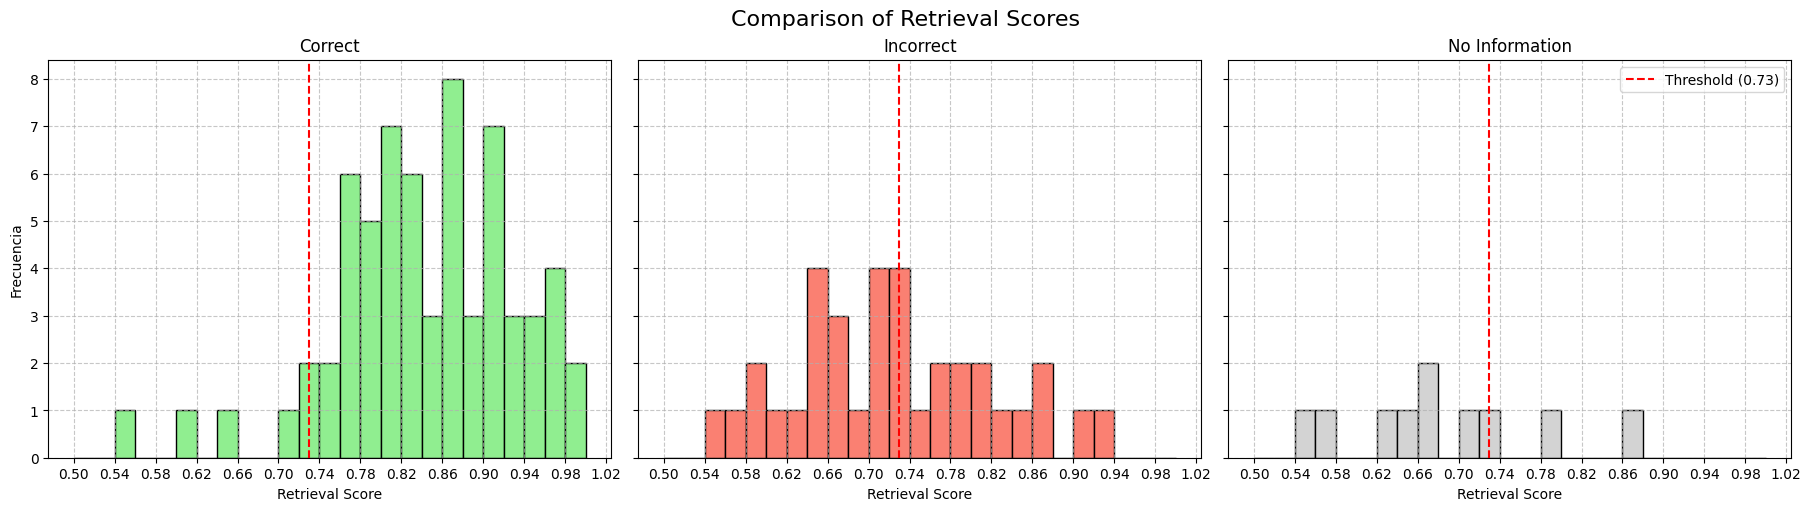

In [12]:
import matplotlib.pyplot as plt
import numpy as np

# Construir una figura (1 row, 3 columns)
fig, axes = plt.subplots(nrows=1, ncols=3, figsize=(18, 5), sharey=True, sharex=True, layout='constrained')

# Definir como se van a agrupar los valores
mis_bins = np.arange(0.5, 1.02, 0.02)

# Graficar cada histograma
#   Correct
correct.hist(column='retrieval_score', bins=mis_bins, ax=axes[0], color='lightgreen', edgecolor='black')
axes[0].set_title('Correct')
axes[0].set_ylabel('Frecuencia')

#   Incorrect
incorrect.hist(column='retrieval_score', bins=mis_bins, ax=axes[1], color='salmon', edgecolor='black')
axes[1].set_title('Incorrect')

#   No Information
no_info.hist(column='retrieval_score', bins=mis_bins, ax=axes[2], color='lightgray', edgecolor='black')
axes[2].set_title('No Information')

# Configuraciones para los gráficos
for ax in axes:
    ax.set_xlabel('Retrieval Score')
    ax.grid(True, linestyle='--', alpha=0.7)
    ax.set_xticks(np.arange(0.5, 1.05, 0.04))

    # Agregar el threshold a los gráficos
    ax.axvline(x=threshold_val, color='red', linestyle='--', linewidth=1.5, label=f'Threshold ({threshold_val})')

# Título y Leyenda
fig.suptitle('Comparison of Retrieval Scores', fontsize=16)
plt.legend()

plt.show()